# Relevant Segment Extraction (RSE)

## Overview

Standard RAG retrieves individual chunks and sends them to the LLM — but what if the answer spans **multiple consecutive chunks**? RSE solves this by **reconstructing contiguous segments** from clusters of relevant chunks.

| Standard Top-k | RSE |
|---|---|
| Returns isolated chunks | Returns **contiguous segments** of the original document |
| May miss chunks between relevant ones | Fills in "sandwiched" chunks for complete context |
| Fixed-size results | **Dynamic-length** segments (short or long as needed) |

## Key Insight

**Relevant chunks tend to cluster within documents.** If chunks 323, 325, 327, and 330 are all relevant, then the entire range 323-330 is probably useful context — even the chunks in between that weren't individually marked as relevant.

## How It Works

1. Retrieve and rerank chunks as usual
2. Assign each chunk a **value** (positive if relevant, negative if irrelevant)
3. Find the **best segments** by solving a constrained maximum-sum subarray problem
4. Return those segments (contiguous runs of chunks)

## Models Used

- **Reranker**: `cross-encoder/ms-marco-MiniLM-L-6-v2` (scores chunk relevance)

![Relevant Segment Extraction](./images/relevant-segment-extraction.svg)

---
## Step 0: Import Packages

In [1]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
from sentence_transformers import CrossEncoder
from langchain_text_splitters import RecursiveCharacterTextSplitter

---
## Step 1: Load the Cross-Encoder Reranker

In [2]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Reranker loaded")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranker loaded


---
## Step 2: Load Document and Split into Chunks

**Important**: RSE requires chunks with **no overlap** so that segments can be reconstructed by simply concatenating consecutive chunks.

In [3]:
FILE_PATH = "data/nike_2023_annual_report.txt"

with open(FILE_PATH, "r") as f:
    text = f.read()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, chunk_overlap=0, length_function=len
)
docs = text_splitter.create_documents([text])
chunks = [doc.page_content for doc in docs]

print(f"Split document into {len(chunks)} chunks (no overlap)")

Split document into 500 chunks (no overlap)


---
## Step 3: Rerank All Chunks and Compute Chunk Values

For each chunk, we compute a **chunk value** that combines:
1. The **absolute relevance** (from the reranker, transformed via a Beta CDF to spread values more uniformly)
2. The **rank** (exponential decay — top-ranked chunks get a boost)

This fusion of score and rank is more robust than using either alone.

In [4]:
query = "Nike consolidated financial statements"
print(f"Query: {query}\n")

decay_rate = 30

# Score every chunk against the query
pairs = [[query, chunk] for chunk in chunks]
scores = reranker.predict(pairs)

# Rank chunks (highest score first)
reranked_indices = np.argsort(scores)[::-1].tolist()
reranked_scores = [scores[i] for i in reranked_indices]

# Compute similarity_scores (transformed) and chunk_values (rank-weighted)
similarity_scores = [0.0] * len(chunks)
chunk_values = [0.0] * len(chunks)

for rank, index in enumerate(reranked_indices):
    # Beta CDF transform: spreads values more uniformly between 0 and 1
    absolute_relevance = beta.cdf(reranked_scores[rank], 0.4, 0.4)
    similarity_scores[index] = absolute_relevance
    # Combine with exponential rank decay
    chunk_values[index] = np.exp(-rank / decay_rate) * absolute_relevance

print(f"Scored {len(chunks)} chunks")
print(f"Top chunk index: {reranked_indices[0]}, score: {chunk_values[reranked_indices[0]]:.4f}")

Query: Nike consolidated financial statements

Scored 500 chunks
Top chunk index: 331, score: 1.0000


---
## Step 4: Visualize Chunk Relevance Across the Document

The x-axis is chunk index (position in the document), y-axis is relevance. Notice how **relevant chunks cluster together** in certain sections.

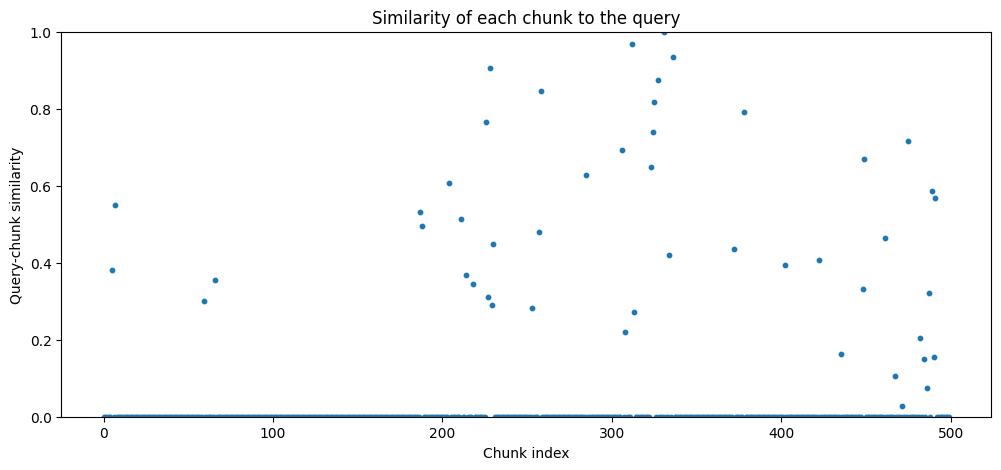

In [5]:
plt.figure(figsize=(12, 5))
plt.title("Similarity of each chunk to the query")
plt.ylim(0, 1)
plt.xlabel("Chunk index")
plt.ylabel("Query-chunk similarity")
plt.scatter(range(len(chunk_values)), chunk_values, s=10)
plt.show()

---
## Step 5: Zoom into the Cluster

Let's zoom in on that cluster of relevant chunks around index 320-340.

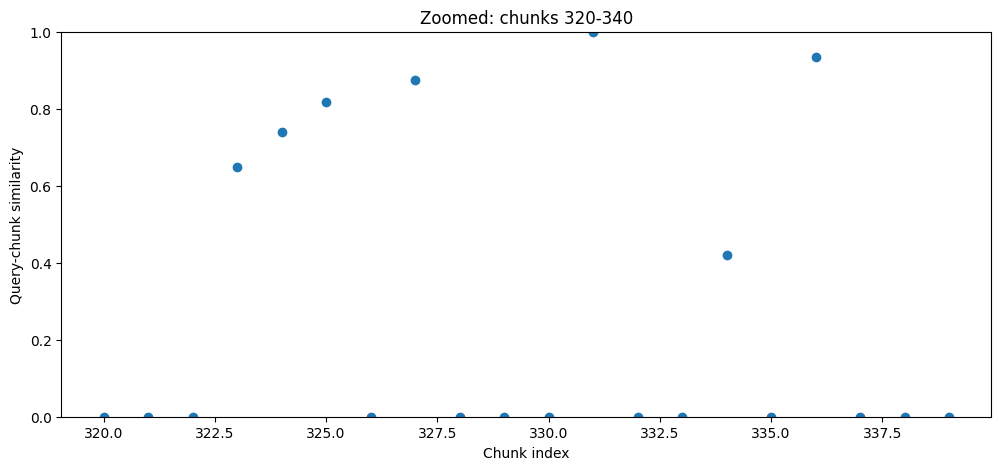

Notice: only about half the chunks are marked as relevant,
but the non-relevant ones are sandwiched between relevant ones.
The entire section is about consolidated financial statements.


In [6]:
start, end = 320, 340

plt.figure(figsize=(12, 5))
plt.title(f"Zoomed: chunks {start}-{end}")
plt.ylim(0, 1)
plt.xlabel("Chunk index")
plt.ylabel("Query-chunk similarity")
plt.scatter(range(start, end), chunk_values[start:end])
plt.show()

print("Notice: only about half the chunks are marked as relevant,")
print("but the non-relevant ones are sandwiched between relevant ones.")
print("The entire section is about consolidated financial statements.")

---
## Step 6: Inspect the Actual Text in That Range

In [7]:
for i in range(320, 340):
    print(f"\n--- Chunk {i} (value: {chunk_values[i]:.3f}) ---")
    print(chunks[i][:200] + "...")


--- Chunk 320 (value: 0.000) ---
financial statements, taken as a whole, and we are not, by communicating the critical audit matter below , providing a separate 
opinion on the critical audit matter or on the accounts or disclosures ...

--- Chunk 321 (value: 0.000) ---
assets is dependent on future taxable earnings. Management assesses the scheduled reversal of deferred tax liabilities, 
projected future taxable income and available tax planning strategies and consi...

--- Chunk 322 (value: 0.000) ---
The principal considerations for our determination that performing procedures relating to the accounting for income taxes is a 
critical audit matter are a high degree of auditor judgment, subjectivit...

--- Chunk 323 (value: 0.648) ---
income taxes, evaluating changes in and compliance with tax laws, and testing the calculation of the provision of income taxes. 
Professionals with specialized skill and knowledge were used to assist ...

--- Chunk 324 (value: 0.741) ---
Total selling 

We can see the Consolidated Statement of Income starts in chunk 323, and everything up to ~333 contains consolidated financial statements. Every chunk in that range is relevant, but only half were marked as such by the reranker. RSE captures the whole section.

---
## Step 7: Find the Best Segments (RSE Optimization)

The algorithm:
1. Subtract a **penalty** (0.2) from each chunk value → irrelevant chunks become negative, relevant stay positive
2. A **segment's value** = sum of its chunk values → clusters of relevant chunks produce high-value segments
3. Find segments with the highest total value (constrained maximum-sum subarray problem)

This is a brute-force search with heuristics — runs in ~5-10ms.

In [8]:
irrelevant_chunk_penalty = 0.2
max_length = 20          # max chunks in one segment
overall_max_length = 30  # max total chunks across all segments
minimum_value = 0.7      # minimum segment score to keep

# Subtract penalty: irrelevant chunks become negative
relevance_values = [v - irrelevant_chunk_penalty for v in chunk_values]

# --- Brute-force segment optimization ---
best_segments = []
segment_scores = []
total_length = 0

while total_length < overall_max_length:
    best_segment = None
    best_value = -1000

    for s in range(len(relevance_values)):
        if relevance_values[s] < 0:
            continue
        for e in range(s + 1, min(s + max_length + 1, len(relevance_values) + 1)):
            if relevance_values[e - 1] < 0:
                continue
            # Skip if overlaps with an existing segment
            if any(s < seg_end and e > seg_start for seg_start, seg_end in best_segments):
                continue
            # Skip if exceeds overall max length
            if total_length + e - s > overall_max_length:
                continue

            segment_value = sum(relevance_values[s:e])
            if segment_value > best_value:
                best_value = segment_value
                best_segment = (s, e)

    if best_segment is None or best_value < minimum_value:
        break

    best_segments.append(best_segment)
    segment_scores.append(best_value)
    total_length += best_segment[1] - best_segment[0]

print("Best segments found:")
for seg, score in zip(best_segments, segment_scores):
    print(f"  Chunks {seg[0]}-{seg[1]-1}  (length: {seg[1]-seg[0]} chunks, score: {score:.3f})")

Best segments found:
  Chunks 323-336  (length: 14 chunks, score: 2.639)
  Chunks 226-230  (length: 5 chunks, score: 1.723)
  Chunks 257-258  (length: 2 chunks, score: 0.927)
  Chunks 312-313  (length: 2 chunks, score: 0.840)
  Chunks 489-491  (length: 3 chunks, score: 0.710)


The first segment (323-336) captures exactly the consolidated financial statements section. We also found a few shorter segments from other parts of the document. These would all be provided to the LLM as context.

---
## Step 8: View the Best Segment

In [9]:
if best_segments:
    seg_start, seg_end = best_segments[0]
    segment_text = "\n".join(chunks[seg_start:seg_end])
    print(f"Best segment: chunks {seg_start}-{seg_end-1} ({seg_end - seg_start} chunks)\n")
    print(segment_text[:2000] + "...")
else:
    print("No segments found")

Best segment: chunks 323-336 (14 chunks)

income taxes, evaluating changes in and compliance with tax laws, and testing the calculation of the provision of income taxes. 
Professionals with specialized skill and knowledge were used to assist in evaluating changes in and compliance with the tax laws 
and regulations and the provision for income taxes.
/s/ PricewaterhouseCoopers LLP
Portland, Oregon
July 20, 2023 
We have served as the Company's auditor since 1974. 
NIKE, INC.      54NIKE, INC.
CONSOLIDATED STATEMENTS OF INCOME
YEAR ENDED MAY 31,
(In millions, except per share data) 2023 2022 2021
Revenues $ 51,217 $ 46,710 $ 44,538 
Cost of sales  28,925  25,231  24,576 
Gross profit  22,292  21,479  19,962 
Demand creation expense  4,060  3,850  3,114 
Operating overhead expense  12,317  10,954  9,911
Total selling and administrative expense  16,377  14,804  13,025 
Interest expense (income), net  (6)  205  262 
Other (income) expense, net  (280)  (181)  14 
Income before income taxes 

---
## Evaluation Results (from the RSE paper)

RSE was evaluated on the KITE benchmark against standard Top-k retrieval (k=20):

| Dataset | Top-k | RSE |
|---|---|---|
| AI Papers | 4.5 | **7.9** |
| BVP Cloud 10-Ks | 2.6 | **4.4** |
| Sourcegraph Handbook | 5.7 | **6.6** |
| Supreme Court Opinions | 6.1 | **8.0** |
| **Average** | **4.72** | **6.73** (+42.6%) |

---
## Summary

| Step | What happened |
|---|---|
| 1-2 | Loaded reranker, split document into 500 chunks (no overlap) |
| 3 | Scored all chunks with CrossEncoder, computed rank-weighted values |
| 4-5 | Visualized relevance distribution — saw clusters of relevant chunks |
| 6 | Inspected the actual text — confirmed entire sections are relevant |
| 7 | **RSE optimization** — found best contiguous segments by maximizing sum of chunk values |
| 8 | Viewed the reconstructed segment |

**Key insight:** RSE bridges the gap between small chunks (precise but incomplete) and large chunks (complete but noisy). By dynamically finding contiguous segments of relevant chunks, it provides the LLM with complete, coherent sections of the original document — including "sandwiched" chunks that the reranker missed but are clearly part of the relevant section.